### 패키지 불러오기 및 전처리

In [14]:
from hossam import load_data
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull
my_dpi = 200


In [15]:
from sklearn.preprocessing import MinMaxScaler

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from scipy.spatial import ConvexHull
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.spatial import ConvexHull

my_dpi = 200


In [16]:
my_dpi = 200 # 이미지 선명도(100~300)
fpath = "./NotoSansKR-Regular.ttf" # 한글을 지원하는 폰트 파일의 경로
fm.fontManager.addfont(fpath) # 폰트의 글꼴을 시스템에 등록함
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트 이름 추출
plt.rcParams['font.family'] = fname # 그래프에 한글 폰트 적용
plt.rcParams['font.size'] = 6 # 기본 폰트 크기
plt.rcParams['axes.unicode_minus'] = False # 그래프에 마이너스 깨짐 방지

### 연습문제

In [17]:
origin = load_data('east_west_airlines')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

항공사의 상용 고객 프로그램에 속한 승객에 대한 정보(마일리지 내역 및 적립 방식 등)를 담고 있는 데이터셋 (출처: https://www.kaggle.com/datasets/singhnproud77/eastwestairlines-heirarchical-clustering)

컬럼명             의미
-----------------  ------------------------------------------------
ID                 고객 고유 식별자
Balance            현재 마일리지 잔액
Qual_miles         최근 1년간 자격 마일리지 (등급 산정용)
cc1_miles          신용카드 유형 1 사용 마일리지 수준 (범주형: 0~5)
cc2_miles          신용카드 유형 2 사용 마일리지 수준 (범주형: 0~5)
cc3_miles          신용카드 유형 3 사용 마일리지 수준 (범주형: 0~5)
Bonus_miles        보너스 마일리지 총합
Bonus_trans        보너스 마일리지 적립 거래 횟수
Flight_miles_12mo  최근 12개월 비행 마일리지
Flight_trans_12    최근 12개월 비행 횟수
Days_since_enroll  프로그램 가입 후 경과 일수
Award              보상(마일리지/혜택) 사용 여부 (0=미사용, 1=사용)


===== 데이터 크기 확인 =====
데이터셋 크기: (3999, 12)
열 개수: 12
행 개수: 3999

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----


,ID,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [53]:
# 전체 결측치 합계를 구함
total_nan = origin.isna().sum().sum()

# f-string을 사용하여 출력
print(f"결측치의 개수는 총 {total_nan}개입니다.")

결측치의 개수는 총 0개입니다.


### 연속형 변수의 기술 통계량

In [18]:
continuous_vars = [
    "Balance",
    "Qual_miles",
    "Bonus_miles",
    "Flight_miles_12mo",
    "Days_since_enroll"
]


In [19]:
origin[continuous_vars].describe().T


,count,mean,std,min,25%,50%,75%,max
Balance,3999.0,73601.327582,100775.664958,0.0,18527.5,43097.0,92404.0,1704838.0
Qual_miles,3999.0,144.114529,773.663804,0.0,0.0,0.0,0.0,11148.0
Bonus_miles,3999.0,17144.846212,24150.967826,0.0,1250.0,7171.0,23800.5,263685.0
Flight_miles_12mo,3999.0,460.055764,1400.209171,0.0,0.0,0.0,311.0,30817.0
Days_since_enroll,3999.0,4118.559390,2065.134540,2.0,2330.0,4096.0,5790.5,8296.0


## 탐색적 데이터 및 데이터 전처리

### 정규분포 여부 확인

In [20]:

fields = [ "Balance", "Flight_miles_12mo","Bonus_miles", "Qual_miles","Flight_trans_12" ]

for f in fields:

    # 정규성 검정
    stat, p = normaltest(origin[f])
    alpha = 0.05

    print(f"\n==== {f} 정규성 검정 ====")
    print(f"stat = {stat}, p = {p}")

    if p > alpha:
        print(f"{f}는 정규분포를 따릅니다 (귀무가설 채택)")
    else:
        print(f"{f}는 정규분포를 따르지 않습니다 (귀무가설 기각)")



==== Balance 정규성 검정 ====
stat = 4124.2072535023335, p = 0.0
Balance는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Flight_miles_12mo 정규성 검정 ====
stat = 5350.852777339507, p = 0.0
Flight_miles_12mo는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Bonus_miles 정규성 검정 ====
stat = 2549.4521767492715, p = 0.0
Bonus_miles는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Qual_miles 정규성 검정 ====
stat = 5258.1689927621155, p = 0.0
Qual_miles는 정규분포를 따르지 않습니다 (귀무가설 기각)

==== Flight_trans_12 정규성 검정 ====
stat = 4324.041619813923, p = 0.0
Flight_trans_12는 정규분포를 따르지 않습니다 (귀무가설 기각)


In [21]:
origin["Balance"].describe()
origin["Bonus_miles"].describe()

count      3999.000000
mean      17144.846212
std       24150.967826
min           0.000000
25%        1250.000000
50%        7171.000000
75%       23800.500000
max      263685.000000
Name: Bonus_miles, dtype: float64

### 로그 변환이 필요한 변수는 무엇인가<br>
KDE plot으로 값 분석

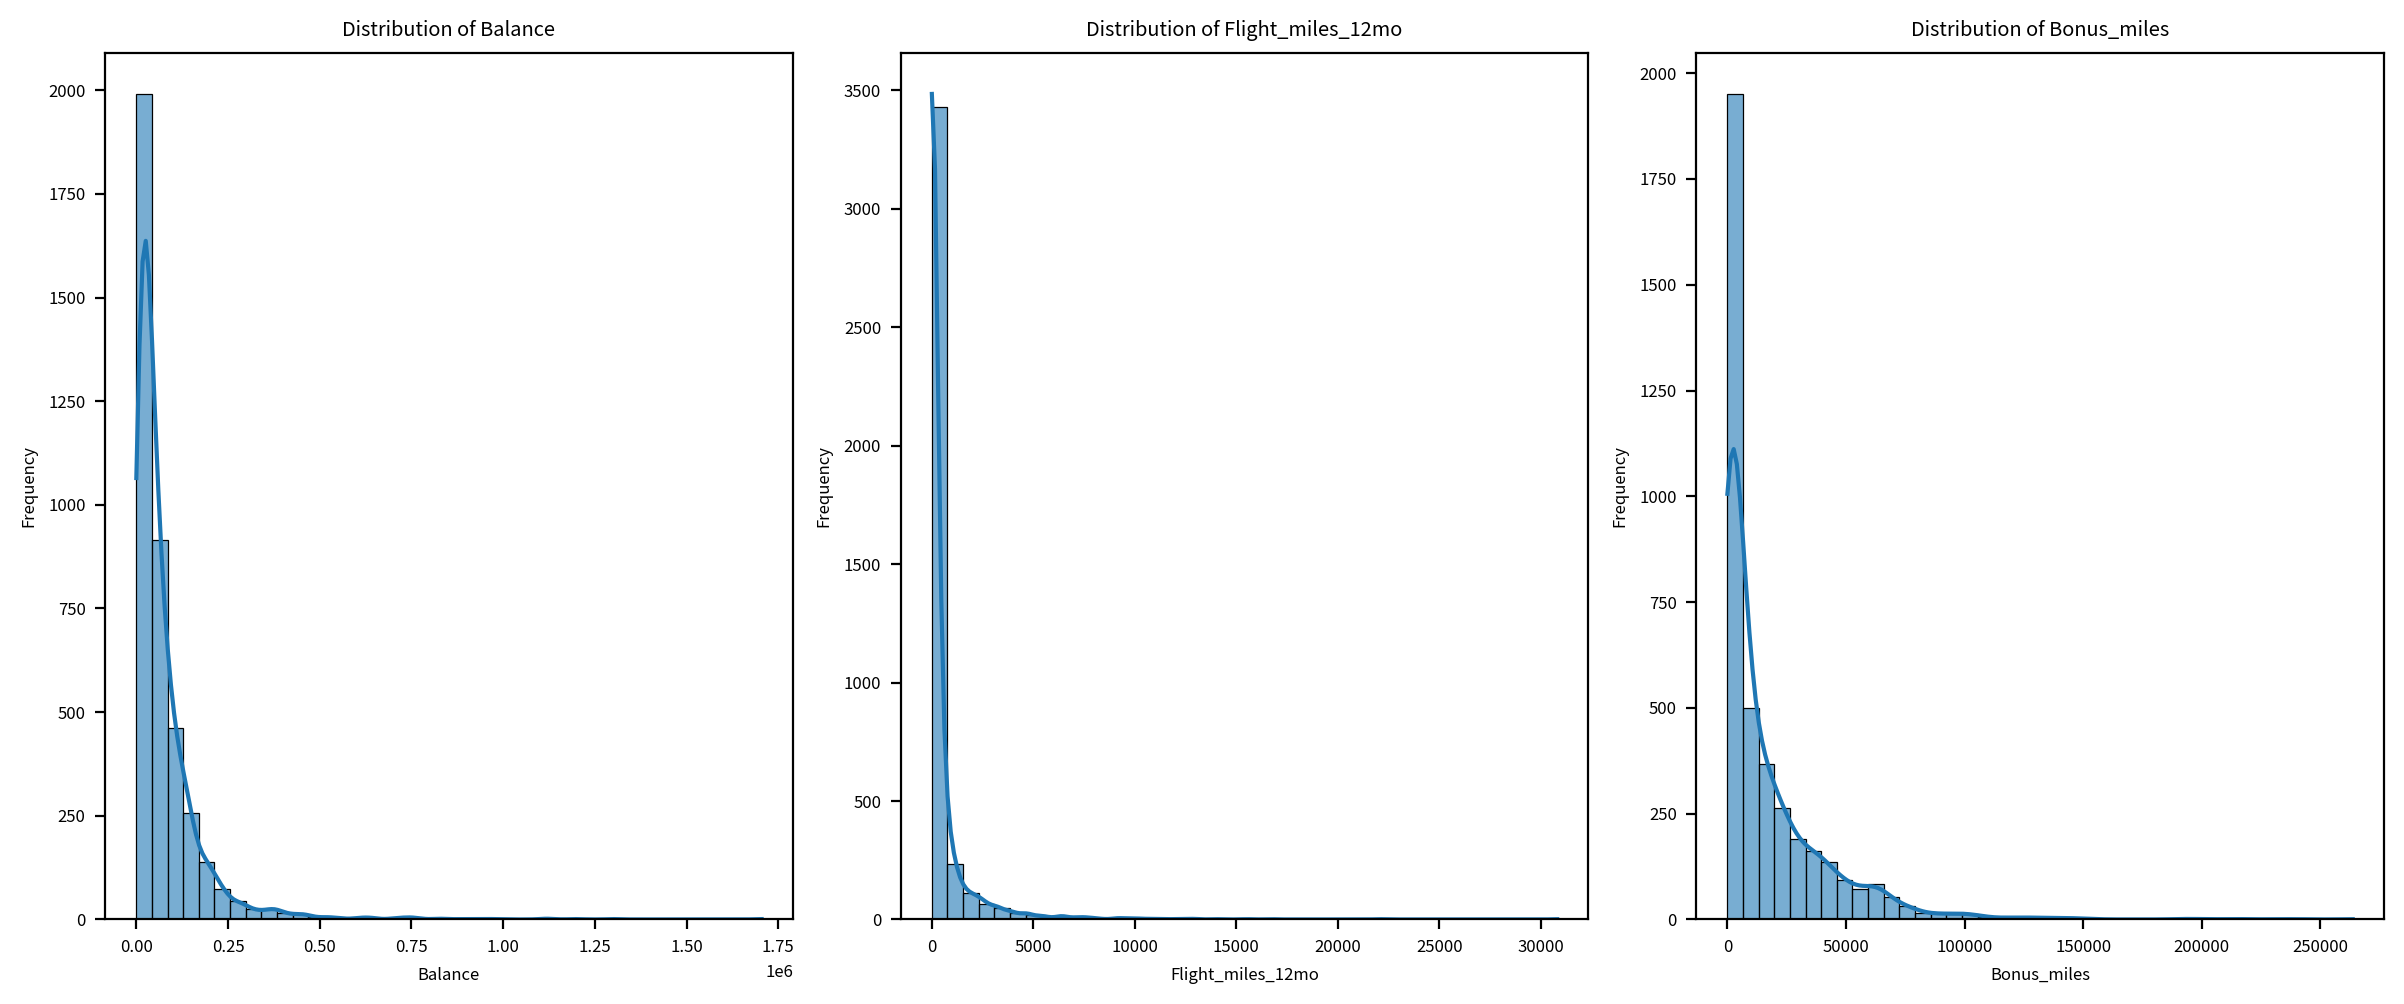

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

fields = ["Balance", "Flight_miles_12mo", "Bonus_miles"]

plt.figure(figsize=(12, 5))

for i, f in enumerate(fields, 1):
    plt.subplot(1, 3, i)
    
    sns.histplot(
        origin[f],
        bins=40,
        kde=True,
        stat="count",
        edgecolor="black",
        alpha=0.6
    )
    
    plt.title(f"Distribution of {f}")
    plt.xlabel(f)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### 상관관계 확인

**스피어만**

In [38]:
valid_corr_vars = [
    "Balance",
    "Bonus_miles",
    "Qual_miles",
    "Flight_miles_12mo",
    "Days_since_enroll",
    "Bonus_trans",
    "Flight_trans_12"
]


In [41]:
corr_matrix = origin[valid_corr_vars].corr(method="spearman")
corr_matrix


,Balance,Bonus_miles,Qual_miles,Flight_miles_12mo,Days_since_enroll,Bonus_trans,Flight_trans_12
Balance,1.000000,0.568392,0.125068,0.304518,0.285786,0.466961,0.301324
Bonus_miles,0.568392,1.000000,0.079596,0.253123,0.220797,0.817123,0.245490
Qual_miles,0.125068,0.079596,1.000000,0.204769,0.028515,0.082789,0.208226
Flight_miles_12mo,0.304518,0.253123,0.204769,1.000000,0.093088,0.295829,0.991406
Days_since_enroll,0.285786,0.220797,0.028515,0.093088,1.000000,0.182753,0.092741
Bonus_trans,0.466961,0.817123,0.082789,0.295829,0.182753,1.000000,0.296904
Flight_trans_12,0.301324,0.245490,0.208226,0.991406,0.092741,0.296904,1.000000


## **가설**<br>
_1.마일리지 잔액 값이 높은 고객이 보너스 마일리지 총합이 높다_

_2.최근 12개월 동안의 비행 횟수가 많은 고객은 마일리지 잔액이 많다_


In [29]:
variable_description = {
    "ID": "고객 고유 식별자 (분석에는 사용하지 않음)",
    "Balance": "현재 고객이 보유한 총 마일리지 잔액",
    "Qual_miles": "최근 1년간 등급 산정을 위해 적립된 마일리지",
    "cc1_miles": "신용카드 유형 1 사용 마일리지 수준 (0~5, 순서형)",
    "cc2_miles": "신용카드 유형 2 사용 마일리지 수준 (0~5, 순서형)",
    "cc3_miles": "신용카드 유형 3 사용 마일리지 수준 (0~5, 순서형)",
    "Bonus_miles": "프로모션·카드 등을 통해 적립된 보너스 마일리지 총합",
    "Bonus_trans": "보너스 마일리지가 적립된 거래 횟수",
    "Flight_miles_12mo": "최근 12개월 동안 실제 비행으로 적립된 마일리지",
    "Flight_trans_12": "최근 12개월 동안의 비행 횟수",
    "Days_since_enroll": "마일리지 프로그램 가입 후 경과 일수",
    "Award": "마일리지 또는 혜택 사용 여부 (0=미사용, 1=사용)"
}

for var, desc in variable_description.items():
    print(f"{var}: {desc}")


ID: 고객 고유 식별자 (분석에는 사용하지 않음)
Balance: 현재 고객이 보유한 총 마일리지 잔액
Qual_miles: 최근 1년간 등급 산정을 위해 적립된 마일리지
cc1_miles: 신용카드 유형 1 사용 마일리지 수준 (0~5, 순서형)
cc2_miles: 신용카드 유형 2 사용 마일리지 수준 (0~5, 순서형)
cc3_miles: 신용카드 유형 3 사용 마일리지 수준 (0~5, 순서형)
Bonus_miles: 프로모션·카드 등을 통해 적립된 보너스 마일리지 총합
Bonus_trans: 보너스 마일리지가 적립된 거래 횟수
Flight_miles_12mo: 최근 12개월 동안 실제 비행으로 적립된 마일리지
Flight_trans_12: 최근 12개월 동안의 비행 횟수
Days_since_enroll: 마일리지 프로그램 가입 후 경과 일수
Award: 마일리지 또는 혜택 사용 여부 (0=미사용, 1=사용)


In [30]:
# 데이터 타입 변환
df = origin.astype(
    {
        "cc1_miles": "category",
        "cc2_miles": "category",
        "cc3_miles": "category",
        "Award": "category",
    }
)

# ID를 인덱스로 설정
df.set_index("ID", inplace=True)

# 데이터 정보 확인
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3999 entries, 1 to 4021
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Balance            3999 non-null   int64   
 1   Qual_miles         3999 non-null   int64   
 2   cc1_miles          3999 non-null   category
 3   cc2_miles          3999 non-null   category
 4   cc3_miles          3999 non-null   category
 5   Bonus_miles        3999 non-null   int64   
 6   Bonus_trans        3999 non-null   int64   
 7   Flight_miles_12mo  3999 non-null   int64   
 8   Flight_trans_12    3999 non-null   int64   
 9   Days_since_enroll  3999 non-null   int64   
 10  Award              3999 non-null   category
dtypes: category(4), int64(7)
memory usage: 266.2 KB


![스크린샷 2026-01-21 150135.png](<attachment:스크린샷 2026-01-21 150135.png>)<br>
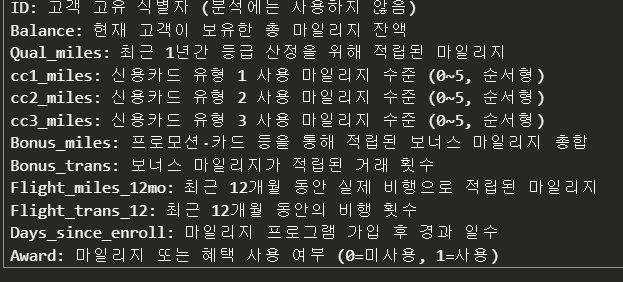

**set_index("고객ID")**<br>
_라벨링_ 

**명목형 -> 연속형**<br>
_서열척도_

**"원-핫 인코딩"**

**2차원 배열**
